<a href="https://colab.research.google.com/github/liminalvoid/nlp/blob/main/sem_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Семинар 2. Domain Shift, наивный Байес, метрики

## Domain Shift/распределения

### Исходные датасеты

В качестве исходных датасетов используются `data-silence/rus_news_classifier` для классификации новостных текстов и `Kostya165/ru_emotion_dvach` для классификации эмоционального интента.

In [1]:
from datasets import load_dataset


rus_news_ds = load_dataset("data-silence/rus_news_classifier")
ru_emotion_ds = load_dataset("Kostya165/ru_emotion_dvach")

rus_news_ds, ru_emotion_ds

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/69.1M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/17.3M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/57530 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/14383 [00:00<?, ? examples/s]

...

train_part_6.csv: 0.00B [00:00, ?B/s]

valid.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/59061 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2507 [00:00<?, ? examples/s]

(DatasetDict({
     train: Dataset({
         features: ['news', 'labels'],
         num_rows: 57530
     })
     test: Dataset({
         features: ['news', 'labels'],
         num_rows: 14383
     })
 }),
 DatasetDict({
     train: Dataset({
         features: ['text', 'label'],
         num_rows: 59061
     })
     validation: Dataset({
         features: ['text', 'label'],
         num_rows: 2507
     })
 }))

### Топ-30 log-odds токенов

Извлечение подвыборок из каждого датасета размером 3000 строк.

In [2]:
import numpy as np


def sample_tests(ds, split, n=2000, text_key="text"):
    idx = np.random.choice(len(ds[split]), size=min(n, len(ds[split])), replace=False)

    return [ds[split][int(i)][text_key] for i in idx]


rus_news_train = sample_tests(rus_news_ds, "train", n=3000, text_key="news")
emotion_train = sample_tests(ru_emotion_ds, "train", n=3000)

print("rus_news sampled:", len(rus_news_train))
print("emotion sampled:", len(emotion_train))

rus_news sampled: 3000
emotion sampled: 3000


Вспомогательные функции для калькуляции log-odds.

In [14]:
import re
import math

from collections import Counter
from typing import List


TOKEN_RE = re.compile(r"[A-Za-z']+")
simple_tokenize = lambda text: TOKEN_RE.findall(text.lower())


def log_odds_with_smoothing(counts_a: Counter, counts_b: Counter, alpha: float = 0.1):
    """Δ(w)=log((c_a(w)+α)/(N_a+α|V|)) - log((c_b(w)+α)/(N_b+α|V|))"""
    vocab = set(counts_a) | set(counts_b)
    V = len(vocab)
    Na = sum(counts_a.values())
    Nb = sum(counts_b.values())
    deltas = {}

    for w in vocab:
        pa = (counts_a[w] + alpha) / (Na + alpha * V)
        pb = (counts_b[w] + alpha) / (Nb + alpha * V)
        deltas[w] = math.log(pa) - math.log(pb)

    return deltas


def count_tokens(texts):
    c = Counter()

    for t in texts:
        if t:
            c.update(simple_tokenize(t.lower()))

    return c


def


def top_log_odds_words(
        texts_a: List[str],
        texts_b: List[str],
        top_n: int = 25,
        alpha: float = 0.1
):
    """
    Функция для калькуляции log-odds для токенов.
    """
    ca = count_tokens(texts_a)
    cb = count_tokens(texts_b)

    deltas = log_odds_with_smoothing(ca, cb, alpha=alpha)
    pos = sorted(deltas.items(), key=lambda x: x[1], reverse=True)[:top_n]
    neg = sorted(deltas.items(), key=lambda x: x[1])[:top_n]

    return pos, neg

Log-odds для подвыборок.

In [4]:
import pandas as pd


pos, neg = top_log_odds_words(rus_news_train, emotion_train, top_n=30)

print("Топ-слова для rus_news (против emotion):")
display(pd.DataFrame(pos, columns=["word", "∆(rus_news - emotion)"]))

print("Топ-слова для emotion (против rus_news):")
display(pd.DataFrame(neg, columns=["word", "∆(emotion - rus_news)"]))

Топ-слова для rus_news (против emotion):


,word,∆(rus_news - emotion)
0,',5.854791
1,telegram,5.527598
2,covid,5.325603
3,instagram,4.741350
4,twitter,4.722499
5,ufc,4.601261
6,microsoft,4.438300
7,bloomberg,4.129753
8,meta,4.076737
9,tiktok,3.919860


Топ-слова для emotion (против rus_news):


,word,∆(emotion - rus_news)
0,is,-6.944528
1,i'm,-6.497678
2,only,-6.497678
3,if,-6.497678
4,sure,-6.166824
5,oh,-5.948570
6,way,-5.948570
7,spaceman,-5.948570
8,there,-5.948570
9,gifx,-5.948570


### Графики распределений

#### Расрпделение длины документов

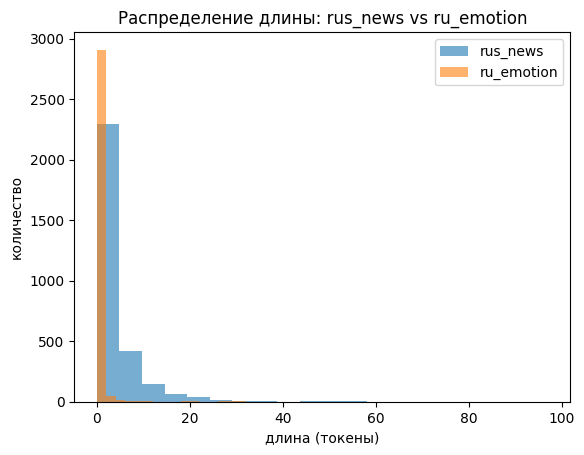

In [9]:
import matplotlib.pyplot as plt


plt.figure()
plt.hist(
    [len(simple_tokenize(t)) for t in rus_news_train],
    bins=20,
    alpha=0.6,
    label="rus_news",
)
plt.hist(
    [len(simple_tokenize(t)) for t in emotion_train],
    bins=20,
    alpha=0.6,
    label="ru_emotion",
)
plt.legend()
plt.title("Распределение длины: rus_news vs ru_emotion")
plt.xlabel("длина (токены)")
plt.ylabel("количество")
plt.show()

#### Закон Ципфа (частоты топ-100 токенов)

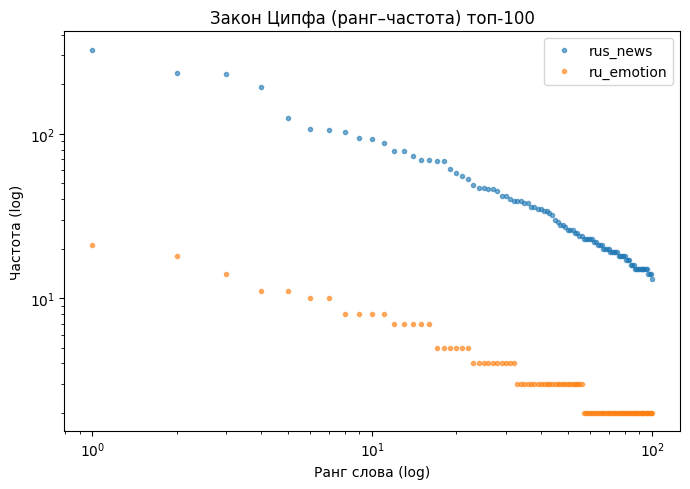

In [24]:
# Zipf данные
rus_news_cnt = count_tokens(rus_news_train)
ru_emotion_cnt = count_tokens(emotion_train)

news_freqs_sorted = np.array([v for _, v in rus_news_cnt.most_common(100)])
news_ranks = np.arange(1, len(news_freqs_sorted) + 1)

emotion_freqs_sorted = np.array([v for _, v in ru_emotion_cnt.most_common(100)])
emotion_ranks = np.arange(1, len(emotion_freqs_sorted) + 1)

# 3.1 Zipf log-log
plt.figure(figsize=(7,5))
# news
plt.loglog(
    news_ranks,
    news_freqs_sorted,
    marker=".",
    linestyle="none",
    label="rus_news",
    alpha=0.6,
)
# emotion
plt.loglog(
    emotion_ranks,
    emotion_freqs_sorted,
    marker=".",
    linestyle="none",
    label="ru_emotion",
    alpha=0.6,
)
plt.legend()
plt.title("Закон Ципфа (ранг–частота) топ-100")
plt.xlabel("Ранг слова (log)")
plt.ylabel("Частота (log)")
plt.tight_layout()
plt.show()

#### Доля чисел/пунктуации